In [113]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
from geopy.distance import geodesic
import joblib

In [114]:
df = pd.read_csv("/content/drive/MyDrive/credit-card-fraud-detection-django-ml/fraud_project/dataset.csv")
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,1/1/2019 0:00,2.700000e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",3/9/1988,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,1/1/2019 0:00,6.300000e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,6/21/1978,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,1/1/2019 0:00,3.890000e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1/19/1962,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,1/1/2019 0:01,3.530000e+15,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1/12/1967,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,1/1/2019 0:03,3.760000e+14,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,3/28/1986,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [115]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day'] = df['trans_date_trans_time'].dt.day
df['month'] = df['trans_date_trans_time'].dt.month

In [116]:
drop_columns = ['Unnamed: 0', 'trans_date_trans_time', 'first', 'last', 'street', 'city', 'state', 'zip', 'dob', 'job', 'trans_num']
df = df.drop(columns=drop_columns)

In [117]:
df.head()

,cc_num,merchant,category,amt,gender,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,hour,day,month
0,2.700000e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495,1325376018,36.011293,-82.048315,0,0,1,1
1,6.300000e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149,1325376044,49.159047,-118.186462,0,0,1,1
2,3.890000e+13,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154,1325376051,43.150704,-112.154481,0,0,1,1
3,3.530000e+15,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939,1325376076,47.034331,-112.561071,0,0,1,1
4,3.760000e+14,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99,1325376186,38.674999,-78.632459,0,0,1,1


In [118]:
cat_col = ['merchant', 'category', 'gender']
encoders = {}
for col in cat_col:
    encoders [col]=LabelEncoder()
    df[col]=encoders [col].fit_transform(df[col])

In [119]:
def haversine (lat1, lon1, lat2, lon2):
    return np.array([geodesic((a,b), (c,d)).km for a,b,c,d in zip (lat1, lon1, lat2, lon2)])
df['distance'] = haversine (df['lat'], df ['long'], df['merch_lat'], df ['merch_long'])

In [120]:
df.head()

,cc_num,merchant,category,amt,gender,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,hour,day,month,distance
0,2.700000e+15,292,8,4.97,0,36.0788,-81.1781,3495,1325376018,36.011293,-82.048315,0,0,1,1,78.773821
1,6.300000e+11,128,4,107.23,0,48.8878,-118.2105,149,1325376044,49.159047,-118.186462,0,0,1,1,30.216618
2,3.890000e+13,213,0,220.11,1,42.1808,-112.2620,4154,1325376051,43.150704,-112.154481,0,0,1,1,108.102912
3,3.530000e+15,198,2,45.00,1,46.2306,-112.1138,1939,1325376076,47.034331,-112.561071,0,0,1,1,95.685115
4,3.760000e+14,157,9,41.96,1,38.4207,-79.4629,99,1325376186,38.674999,-78.632459,0,0,1,1,77.702395


In [121]:
features = ['merchant', 'category', 'amt', 'cc_num', 'hour', 'day', 'month', 'gender', 'distance']
x = df[features]
y = df['is_fraud']

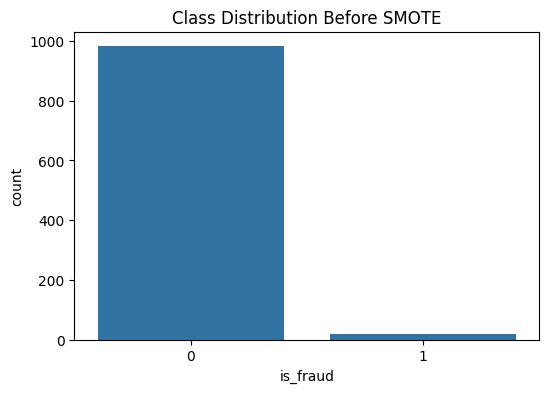

In [122]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=df)
plt.title("Class Distribution Before SMOTE")
plt.show()

In [123]:
smote = SMOTE(random_state=42)
x_resample, y_resample = smote.fit_resample(x,y)

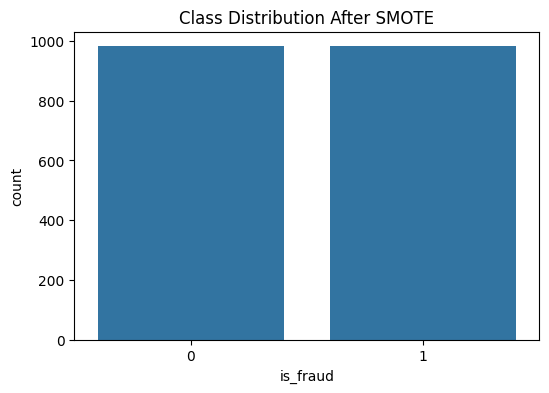

In [124]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_resample)
plt.title("Class Distribution After SMOTE")
plt.show()

In [125]:
x_train, x_test, y_train, y_test = train_test_split(x_resample, y_resample, test_size=0.2, random_state=42)

In [126]:
lgb_model = lgb.LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    metrics='auc',
    is_unbalance=True,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=1,
    n_estimators=200
)
lgb_model.fit(x_train, y_train)

[LightGBM] [Info] Number of positive: 792, number of negative: 779
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000166 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1043
[LightGBM] [Info] Number of data points in the train set: 1571, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.504137 -> initscore=0.016550
[LightGBM] [Info] Start training from score 0.016550
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

LGBMClassifier(is_unbalance=True, learning_rate=0.05, max_depth=1,
               metrics='auc', n_estimators=200, objective='binary')

In [127]:
y_pred = lgb_model.predict(x_test)

In [128]:
print("Classification_Report:\n", classification_report(y_test, y_pred))
print("Roc AUC Score: ", roc_auc_score(y_test, y_pred))

Classification_Report:
               precision    recall  f1-score   support

           0       0.82      0.73      0.77       203
           1       0.74      0.83      0.78       190

    accuracy                           0.78       393
   macro avg       0.78      0.78      0.78       393
weighted avg       0.78      0.78      0.78       393

Roc AUC Score:  0.780321493388644


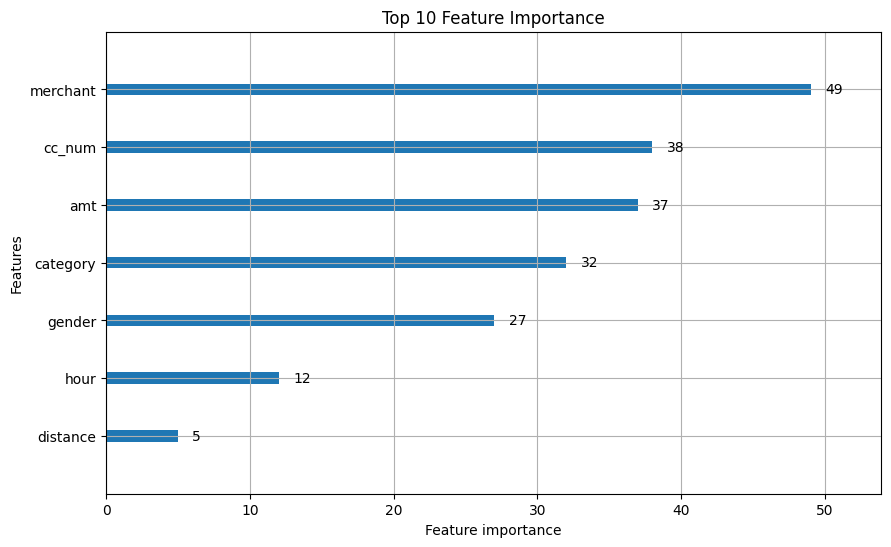

In [129]:
lgb.plot_importance(lgb_model, max_num_features=10, importance_type='split', figsize=(10,6))
plt.title("Top 10 Feature Importance")
plt.show()

In [130]:
fpr, tpr, thresholds = roc_curve(y_test, lgb_model.predict_proba(x_test)[:, 1])
roc_auc = auc(fpr, tpr)

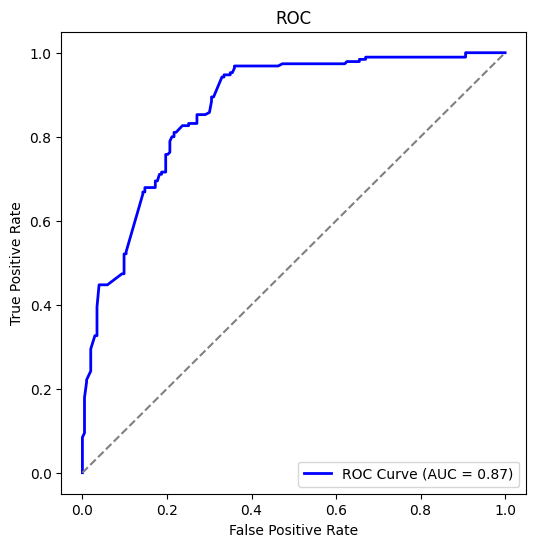

In [131]:
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.title('ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

In [132]:
import os
import joblib
from google.colab import drive

# 1. Mount Drive (if not already mounted)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Define the directory and file paths
drive_path = "/content/drive/MyDrive/credit-card-fraud-detection-django-ml/fraud_project/predictor"
model_file = os.path.join(drive_path, 'fraud_detection_model.jb')
encoder_file = os.path.join(drive_path, 'label_encoder.jb')

# 3. Create the directory if it doesn't exist
os.makedirs(drive_path, exist_ok=True)

# 4. Logical check for Model
if os.path.exists(model_file):
    print(f"✅ Model found: '{model_file}' already exists. Skipping save.")
else:
    print("🚀 Model not found. Saving 'fraud_detection_model.jb'...")
    joblib.dump(lgb_model, model_file)
    print("✅ Model saved successfully.")

# 5. Logical check for Encoder
if os.path.exists(encoder_file):
    print(f"✅ Encoder found: '{encoder_file}' already exists. Skipping save.")
else:
    print("🚀 Encoder not found. Saving 'label_encoder.jb'...")
    joblib.dump(encoders, encoder_file)
    print("✅ Encoder saved successfully.")

# Optional: List files to confirm
print("\nCurrent files in predictor directory:", os.listdir(drive_path))

✅ Model found: '/content/drive/MyDrive/credit-card-fraud-detection-django-ml/fraud_project/predictor/fraud_detection_model.jb' already exists. Skipping save.
✅ Encoder found: '/content/drive/MyDrive/credit-card-fraud-detection-django-ml/fraud_project/predictor/label_encoder.jb' already exists. Skipping save.

Current files in predictor directory: ['__init__.py', 'apps.py', 'tests.py', 'models.py', 'views.py', 'urls.py', 'admin.py', '__pycache__', 'migrations', 'fraud_detection_model.jb', 'label_encoder.jb']
